# NeuralProphet

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_error


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


## Load Dataset

In [2]:
df = pd.read_csv('metro_interstate_traffic_volume.csv')

df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df[['ds','y']].sort_values('ds').dropna()


## Data Cleaning & Missing Values

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
df['y'] = df['y'].fillna(method='ffill').fillna(method='bfill')

# Resample per hari

In [4]:
df = df.set_index('ds').asfreq('D')
df['y'] = df['y'].interpolate()
df = df.reset_index()

## Train / Validation / Test Split (70/10/20)

In [5]:
train_size = int(len(df)*0.7)
val_size   = int(len(df)*0.1)

train_df = df[:train_size]
val_df   = df[train_size:train_size+val_size]
test_df  = df[train_size+val_size:]

## Model (NeuralProphet)

In [6]:
model = NeuralProphet(
    n_forecasts=1,
    n_lags=14,
    yearly_seasonality=False,  # traffic volume biasanya tidak ada yearly seasonality
    weekly_seasonality=True,
    epochs=200
)

## Training with Early Stopping

In [7]:
model.fit(
    train_df,
    freq='D',
    validation_df=val_df,
    early_stopping=True,
    progress='bar'
)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.935% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (48) is too small than the required number                     for the learning rate finder (230). The results might not be optimal.


Finding best initial lr:   0%|          | 0/230 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,17079.458984,18150.640625,3.007600,0.0,0,2.537338,0.0,18806.910156,19577.652344,2.530713,0.0
1,9856.828125,11611.174805,1.672456,0.0,1,1.609103,0.0,12229.504883,13389.561523,1.604990,0.0
2,5505.494141,6968.456543,0.872047,0.0,2,0.792475,0.0,6424.115234,8098.751953,0.790770,0.0
3,4765.685547,5631.590820,0.739280,0.0,3,0.495860,0.0,4367.477051,5442.071289,0.496135,0.0
4,4254.387207,5084.030762,0.644769,0.0,4,0.420673,0.0,3804.419678,4660.492676,0.419032,0.0
...,...,...,...,...,...,...,...,...,...,...,...
195,339.711090,483.463989,0.013024,0.0,195,0.014620,0.0,427.799561,595.589783,0.014519,0.0
196,339.538086,483.298950,0.013013,0.0,196,0.014620,0.0,428.914032,595.382935,0.014594,0.0
197,339.316162,482.648468,0.012961,0.0,197,0.014595,0.0,428.056000,591.653687,0.014555,0.0
198,339.375610,482.998169,0.012992,0.0,198,0.014592,0.0,428.218384,599.084106,0.014671,0.0


## Forecast & Evaluation

In [8]:
forecast = model.predict(df)

forecast_test = forecast.iloc[-len(test_df):].copy()
forecast_test = forecast_test[['yhat1']].dropna()

y_pred = forecast_test['yhat1'].values
y_true = test_df['y'].iloc[:len(y_pred)].values

mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.954% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.954% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


## Metrics

In [9]:
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom[denom == 0] = 1e-8
    return 100/len(y_true) * np.sum(2*np.abs(y_pred - y_true)/denom)

def mase(y_true, y_pred, y_train):
    naive = np.mean(np.abs(np.diff(y_train)))
    if naive == 0:
        naive = 1e-8
    return np.mean(np.abs(y_true - y_pred)) / naive

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
smape_val = smape(y_true, y_pred)
mase_val = mase(y_true, y_pred, train_df['y'].values)

print('RMSE:', rmse)
print('MAE :', mae)
print('sMAPE:', smape_val)
print('MASE :', mase_val)

RMSE: 578.5463229100357
MAE : 394.6377900702768
sMAPE: 9.97333568724178
MASE : 0.7052315031245863


## Plot

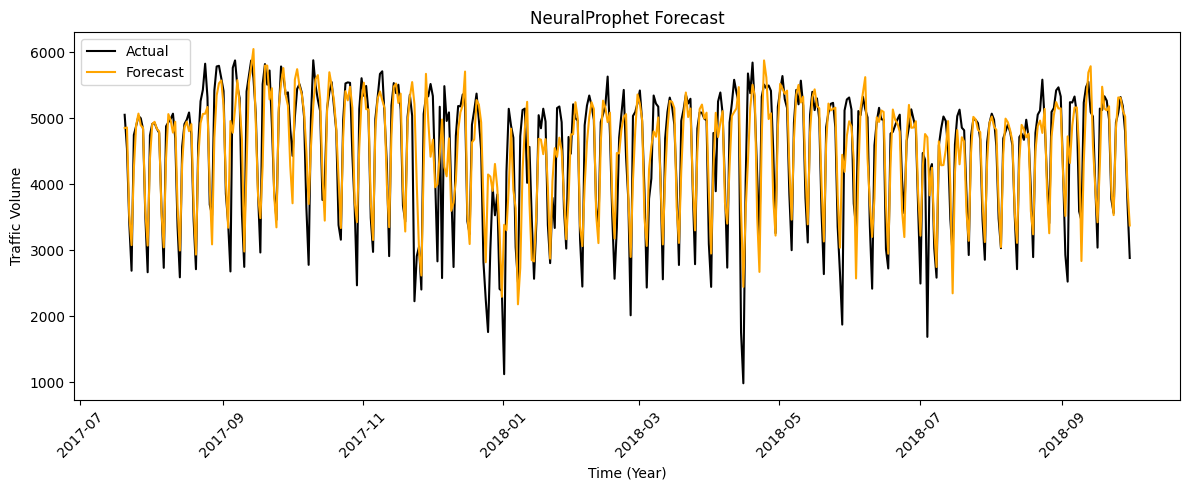

In [11]:
ds_test = test_df["ds"].iloc[:len(y_true)]

plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label="Actual", color="black")
plt.plot(ds_test, y_pred, label="Forecast", color="orange")

plt.title("NeuralProphet Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Traffic Volume")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()